In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Churn_Modelling.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# BASIC INFORMATION OF DATASET

In [ ]:
print(df.shape)

(10000, 14)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [ ]:
print(df.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


# REMOVE UNNECESSARY COLUMNS

In [ ]:
df.drop(['RowNumber', 'CustomerId', 'Surname'],
        axis=1, inplace=True)

#DUPLICATE REMOVE

In [ ]:

df.drop_duplicates(inplace=True)

print("Clean dataset shape:", df.shape)

Clean dataset shape: (10000, 11)


#CHURN COUNT

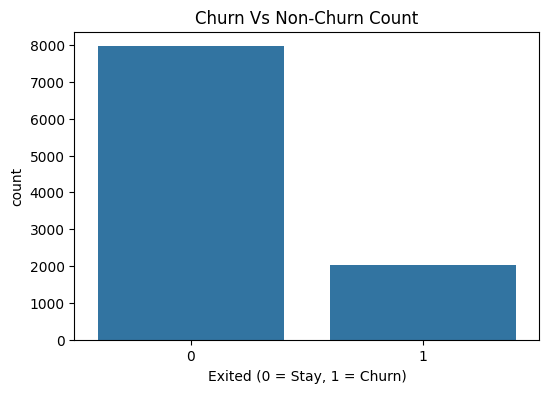

Exited
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df)
plt.title('Churn Vs Non-Churn Count')
plt.xlabel('Exited (0 = Stay, 1 = Churn)')
plt.savefig('churn_count.png')
plt.show()

print(df['Exited'].value_counts())

#AGE VS CHURN

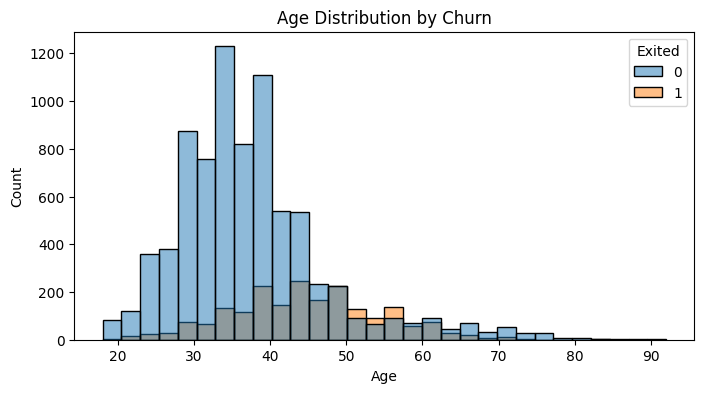

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', hue='Exited', bins=30)
plt.title('Age Distribution by Churn')
plt.savefig('age_churn.png')
plt.show()


#AGE VS CHURN

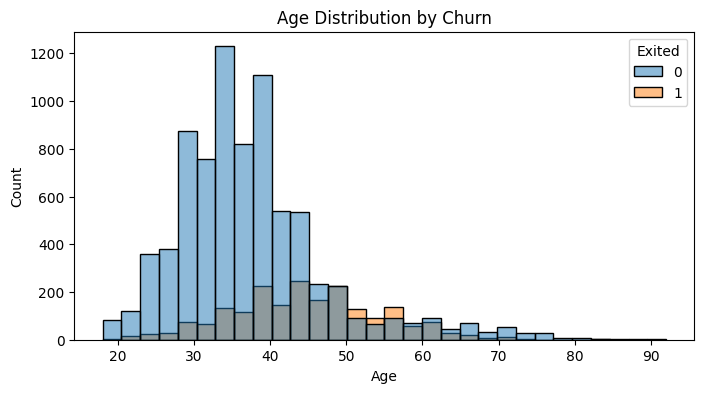

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age',
             hue='Exited', bins=30)
plt.title('Age Distribution by Churn')
plt.savefig('age_churn.png')
plt.show()

#GEOGRAPHY VS CHURN

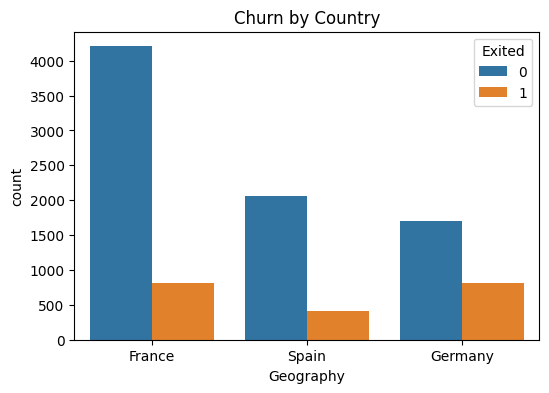

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Geography',
              hue='Exited', data=df)
plt.title('Churn by Country')
plt.savefig('geo_churn.png')
plt.show()

#BALANCE VS CHURN

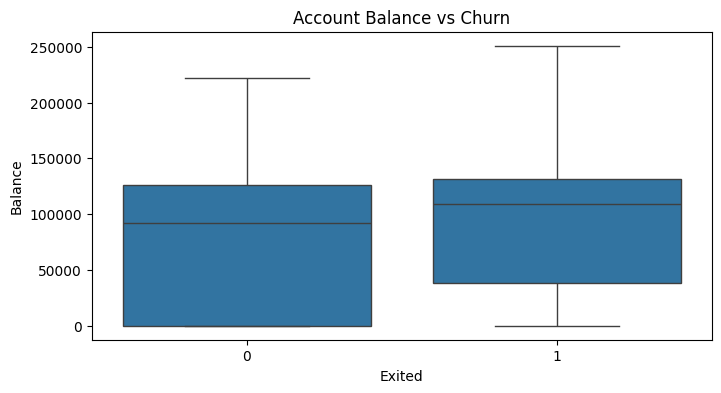

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Account Balance vs Churn')
plt.savefig('balance_churn.png')
plt.show()

#KEY INSIGHTS

In [ ]:
print("\n1. Churn Rate Overall:")
print(round(df['Exited'].mean()*100, 2), "%")


1. Churn Rate Overall:
20.37 %


In [ ]:
print("\n2. Churn by Country:")
print(df.groupby('Geography')['Exited']
      .mean().mul(100).round(2))



2. Churn by Country:
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64


In [ ]:
print("\n3. Churn by Gender:")
print(df.groupby('Gender')['Exited']
      .mean().mul(100).round(2))


3. Churn by Gender:
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64


In [ ]:

print("\n4. Active vs Inactive Churn:")
print(df.groupby('IsActiveMember')['Exited']
      .mean().mul(100).round(2))


4. Active vs Inactive Churn:
IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


In [ ]:
print("\n5. Avg Age - Churned vs Not:")
print(df.groupby('Exited')['Age']
      .mean().round(2))


5. Avg Age - Churned vs Not:
Exited
0    37.41
1    44.84
Name: Age, dtype: float64


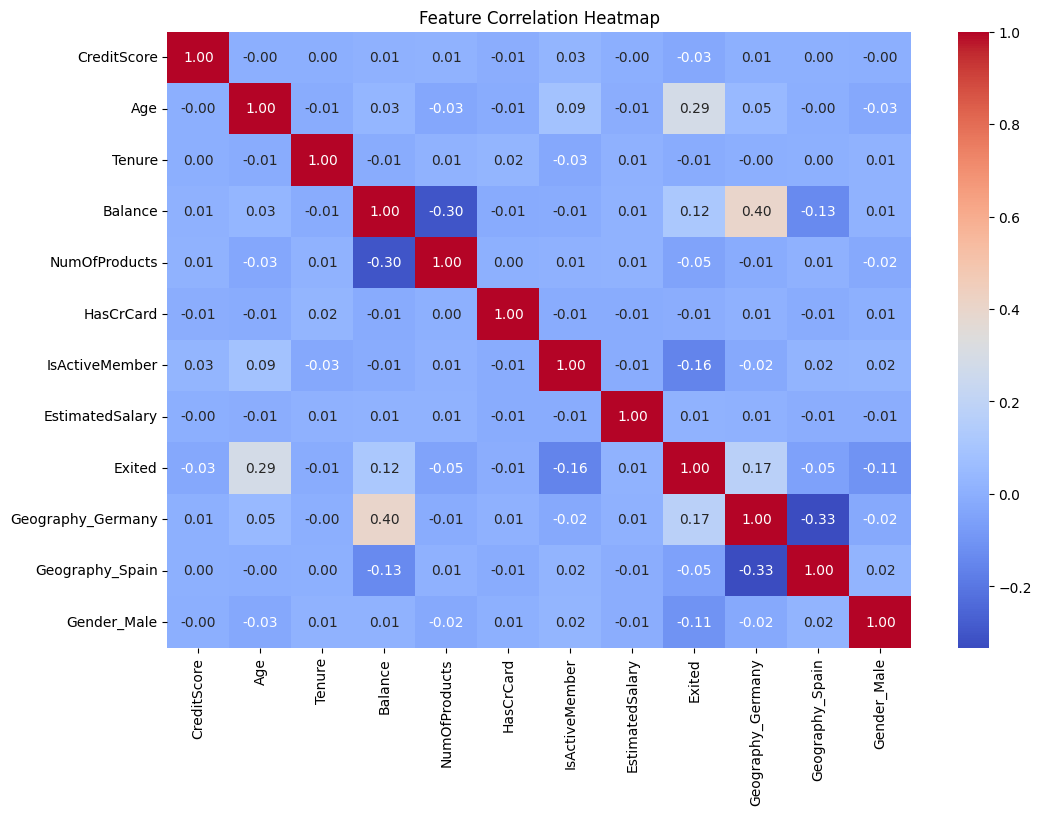

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('heatmap.png')
plt.show()